In [0]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
#Extract
df = spark.read.csv("/Volumes/workspace/default/churn_data/WA_Fn-UseC_-Telco-Customer-Churn.csv",
    header=True,
    inferSchema=True)

# What the data looks like
print(f"Shape: {df.count()} rows x {len(df.columns)} columns")
print("\nColumns:")
for col in df.columns:
    print(f"  {col}")

df.show(5)



Shape: 7043 rows x 21 columns

Columns:
  customerID
  gender
  SeniorCitizen
  Partner
  Dependents
  tenure
  PhoneService
  MultipleLines
  InternetService
  OnlineSecurity
  OnlineBackup
  DeviceProtection
  TechSupport
  StreamingTV
  StreamingMovies
  Contract
  PaperlessBilling
  PaymentMethod
  MonthlyCharges
  TotalCharges
  Churn
+----------+------+-------------+-------+----------+------+------------+----------------+---------------+--------------+------------+----------------+-----------+-----------+---------------+--------------+----------------+--------------------+--------------+------------+-----+
|customerID|gender|SeniorCitizen|Partner|Dependents|tenure|PhoneService|   MultipleLines|InternetService|OnlineSecurity|OnlineBackup|DeviceProtection|TechSupport|StreamingTV|StreamingMovies|      Contract|PaperlessBilling|       PaymentMethod|MonthlyCharges|TotalCharges|Churn|
+----------+------+-------------+-------+----------+------+------------+----------------+-------------

In [0]:
# See data types and check for nulls
df_pandas = df.toPandas()
print("Data Types")
df.printSchema()

print("Missing Values")
print(df_pandas.isnull().sum())

print("Churn Distrubition")

df.groupBy("Churn").count().show()

Data Types
root
 |-- customerID: string (nullable = true)
 |-- gender: string (nullable = true)
 |-- SeniorCitizen: integer (nullable = true)
 |-- Partner: string (nullable = true)
 |-- Dependents: string (nullable = true)
 |-- tenure: integer (nullable = true)
 |-- PhoneService: string (nullable = true)
 |-- MultipleLines: string (nullable = true)
 |-- InternetService: string (nullable = true)
 |-- OnlineSecurity: string (nullable = true)
 |-- OnlineBackup: string (nullable = true)
 |-- DeviceProtection: string (nullable = true)
 |-- TechSupport: string (nullable = true)
 |-- StreamingTV: string (nullable = true)
 |-- StreamingMovies: string (nullable = true)
 |-- Contract: string (nullable = true)
 |-- PaperlessBilling: string (nullable = true)
 |-- PaymentMethod: string (nullable = true)
 |-- MonthlyCharges: double (nullable = true)
 |-- TotalCharges: string (nullable = true)
 |-- Churn: string (nullable = true)

Missing Values
customerID          0
gender              0
SeniorCitiz

In [0]:
# Statistical summary of numeric columns
df_pandas['TotalCharges'] = pd.to_numeric(df_pandas['TotalCharges'], errors='coerce')
df_pandas[['tenure', 'MonthlyCharges', 'TotalCharges']].describe()

,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7032.000000
mean,32.371149,64.761692,2283.300441
std,24.559481,30.090047,2266.771362
min,0.000000,18.250000,18.800000
25%,9.000000,35.500000,401.450000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.850000,3794.737500
max,72.000000,118.750000,8684.800000


In [0]:
# Check if nulls in TotalCharges match customers with tenure = 0
df_pandas[df_pandas['tenure'] == 0][['customerID', 'tenure', 'TotalCharges']]

,customerID,tenure,TotalCharges
488,4472-LVYGI,0,NaN
753,3115-CZMZD,0,NaN
936,5709-LVOEQ,0,NaN
1082,4367-NUYAO,0,NaN
1340,1371-DWPAZ,0,NaN
3331,7644-OMVMY,0,NaN
3826,3213-VVOLG,0,NaN
4380,2520-SGTTA,0,NaN
5218,2923-ARZLG,0,NaN
6670,4075-WKNIU,0,NaN


In [0]:
# For customers with tenure = 0 and no TotalCharges fill with zero

df_pandas['TotalCharges'] = df_pandas['TotalCharges'].fillna(0)

#Verify no more nulls
print(df_pandas['TotalCharges'].isnull().sum())

0


In [0]:
#Transform
print(df_pandas.dtypes)

customerID           object
gender               object
SeniorCitizen         int32
Partner              object
Dependents           object
tenure                int32
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object


In [0]:
#Change SeniorCitizen from 0/1 to Yes/No
df_pandas['SeniorCitizen'] = df_pandas['SeniorCitizen'].map({1:'Yes', 0:'No'})

#Check for duplicates
print("Duplicate rows: ", df_pandas.duplicated().sum())

#Strip whitespace in columns
object_cols = df_pandas.select_dtypes(include='object').columns
for col in object_cols:
    df_pandas[col] = df_pandas[col].str.strip()

print("Basic cleaning done")
print("Shape ", df_pandas.shape)
print("Updated data types: ")
print(df_pandas.dtypes)

Duplicate rows:  0
Basic cleaning done
Shape  (7043, 21)
Updated data types: 
customerID           object
gender               object
SeniorCitizen        object
Partner              object
Dependents           object
tenure                int32
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object


In [0]:
#Drop duplicate rows
df_pandas = df_pandas.drop_duplicates()

#Check for duplicates
print("Duplicates: ",df_pandas.duplicated().sum())
print("Shape after removing duplicates: ", df_pandas.shape)

Duplicates:  0
Shape after removing duplicates:  (7043, 21)


In [0]:
#Check for unique values in categorical columns
object_cols = df_pandas.select_dtypes(include='object').columns

for col in object_cols:
    print(f"\n{col}: {df_pandas[col].unique()}")


customerID: ['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']

gender: ['Female' 'Male']

SeniorCitizen: ['No' 'Yes']

Partner: ['Yes' 'No']

Dependents: ['No' 'Yes']

PhoneService: ['No' 'Yes']

MultipleLines: ['No phone service' 'No' 'Yes']

InternetService: ['DSL' 'Fiber optic' 'No']

OnlineSecurity: ['No' 'Yes' 'No internet service']

OnlineBackup: ['Yes' 'No' 'No internet service']

DeviceProtection: ['No' 'Yes' 'No internet service']

TechSupport: ['No' 'Yes' 'No internet service']

StreamingTV: ['No' 'Yes' 'No internet service']

StreamingMovies: ['No' 'Yes' 'No internet service']

Contract: ['Month-to-month' 'One year' 'Two year']

PaperlessBilling: ['Yes' 'No']

PaymentMethod: ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']

Churn: ['No' 'Yes']


In [0]:
# Checking what values exist in SeniorCitizen
print(df_pandas['SeniorCitizen'].value_counts(dropna=False))
print(df_pandas['SeniorCitizen'].dtype)
print(df_pandas['SeniorCitizen'].head(20))

SeniorCitizen
No     5901
Yes    1142
Name: count, dtype: int64
object
0     No
1     No
2     No
3     No
4     No
5     No
6     No
7     No
8     No
9     No
10    No
11    No
12    No
13    No
14    No
15    No
16    No
17    No
18    No
19    No
Name: SeniorCitizen, dtype: object


In [0]:
# Checking what the original spark df has for SeniorCitizen
df.select('SeniorCitizen').distinct().show()

+-------------+
|SeniorCitizen|
+-------------+
|            1|
|            0|
+-------------+



In [0]:
# Checking current unique values in SeniorCitizen before fixing
print("Before fix:", df_pandas['SeniorCitizen'].unique())
# Reload SeniorCitizen from original spark df and remap
df_pandas['SeniorCitizen'] = df.toPandas()['SeniorCitizen'].map({1: 'Yes', 0: 'No'})
# Verify fix worked
print("After fix:", df_pandas['SeniorCitizen'].value_counts())

Before fix: ['No' 'Yes']
After fix: SeniorCitizen
No     5901
Yes    1142
Name: count, dtype: int64


In [0]:
# Recheck all categorical columns
object_cols = df_pandas.select_dtypes(include='object').columns

for col in object_cols:
    print(f"\n{col}: {df_pandas[col].unique()}")


customerID: ['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']

gender: ['Female' 'Male']

SeniorCitizen: ['No' 'Yes']

Partner: ['Yes' 'No']

Dependents: ['No' 'Yes']

PhoneService: ['No' 'Yes']

MultipleLines: ['No phone service' 'No' 'Yes']

InternetService: ['DSL' 'Fiber optic' 'No']

OnlineSecurity: ['No' 'Yes' 'No internet service']

OnlineBackup: ['Yes' 'No' 'No internet service']

DeviceProtection: ['No' 'Yes' 'No internet service']

TechSupport: ['No' 'Yes' 'No internet service']

StreamingTV: ['No' 'Yes' 'No internet service']

StreamingMovies: ['No' 'Yes' 'No internet service']

Contract: ['Month-to-month' 'One year' 'Two year']

PaperlessBilling: ['Yes' 'No']

PaymentMethod: ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']

Churn: ['No' 'Yes']


In [0]:
#Load
#Convert clean pandas df to Spark DataFrame
df_clean = spark.createDataFrame(df_pandas)
# Save as a Delta table in Databricks
df_clean.write.mode("overwrite").saveAsTable("workspace.default.telco_churn_clean")

print("Clean data saved as Delta table")
print("Final Shape: ",df_pandas.shape)


---------------------------------------------------------------------------
AnalysisException                         Traceback (most recent call last)
File <command-4898573273294087>, line 5
      3 df_clean = spark.createDataFrame(df_pandas)
      4 # Save as a Delta table in Databricks
----> 5 df_clean.write.mode("overwrite").saveAsTable("workspace.default.telco_churn_clean")
      7 print("Clean data saved as Delta table")
      8 print("Final Shape: ",df_pandas.shape)

File /databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/readwriter.py:737, in DataFrameWriter.saveAsTable(self, name, format, mode, partitionBy, **options)
    735 self._write.table_name = name
    736 self._write.table_save_method = "save_as_table"
--> 737 _, _, ei = self._spark.client.execute_command(
    738     self._write.command(self._spark.client), self._write.observations
    739 )
    740 self._callback(ei)

File /databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/client/cor

In [0]:
# COHORT ANALYSIS

#Create tenure-based cohorts
df_pandas['tenure_cohort'] = pd.cut(
    df_pandas['tenure'],
    bins=[0, 12, 24, 48, 72],
    labels=['0-12 months', '13-24 months', '25-48 months', '49-72 months']
)

# Verify cohorts were created
print(df_pandas['tenure_cohort'].value_counts().sort_index())

tenure_cohort
0-12 months     2175
13-24 months    1024
25-48 months    1594
49-72 months    2239
Name: count, dtype: int64


In [0]:
# Calculate churn rate per cohort
cohort_churn = df_pandas.groupby('tenure_cohort').agg(
    total_customers=('Churn', 'count'),
    churned=('Churn', lambda x: (x == 'Yes').sum())
).reset_index()

# Calculate churn rate percentage
cohort_churn['churn_rate_pct'] = (
    cohort_churn['churned'] / cohort_churn['total_customers'] * 100
).round(2)

print(cohort_churn)

  tenure_cohort  total_customers  churned  churn_rate_pct
0   0-12 months             2175     1037           47.68
1  13-24 months             1024      294           28.71
2  25-48 months             1594      325           20.39
3  49-72 months             2239      213            9.51


/home/spark-1240c256-c9ce-45d5-8226-eb/.ipykernel/2038/command-6130264952327676-2115467378:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cohort_churn = df_pandas.groupby('tenure_cohort').agg(


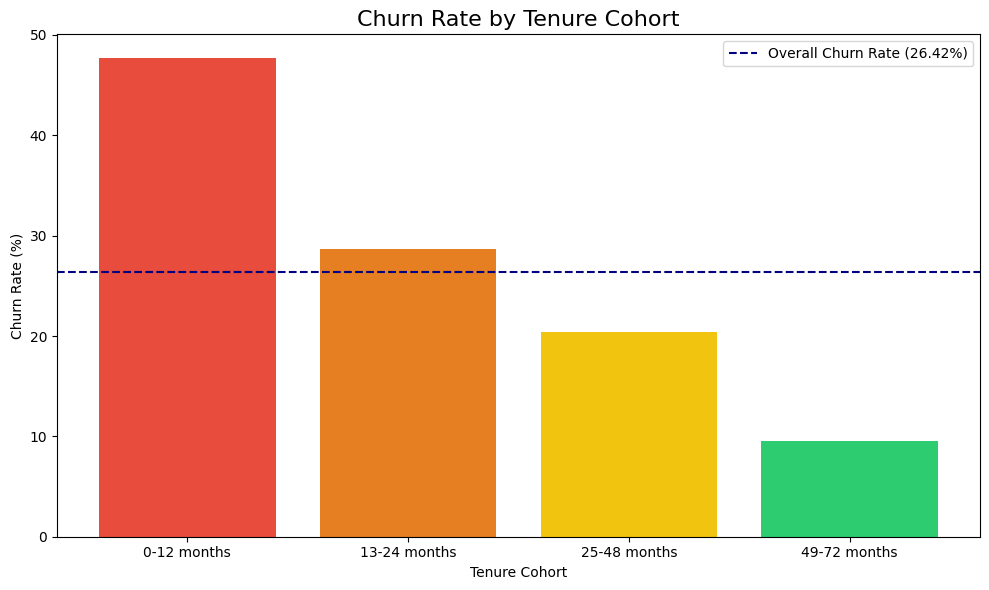

In [0]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.bar(cohort_churn['tenure_cohort'], cohort_churn['churn_rate_pct'], color=['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71'])
plt.axhline(y=26.42, color='navy', linestyle='--', label='Overall Churn Rate (26.42%)')
plt.title('Churn Rate by Tenure Cohort', fontsize=16)
plt.xlabel('Tenure Cohort')
plt.ylabel('Churn Rate (%)')
plt.legend()
plt.tight_layout()
plt.show()

/home/spark-1240c256-c9ce-45d5-8226-eb/.ipykernel/2038/command-6130264952327678-2283659915:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cohort_contract = df_pandas.groupby(['tenure_cohort', 'Contract']).agg(


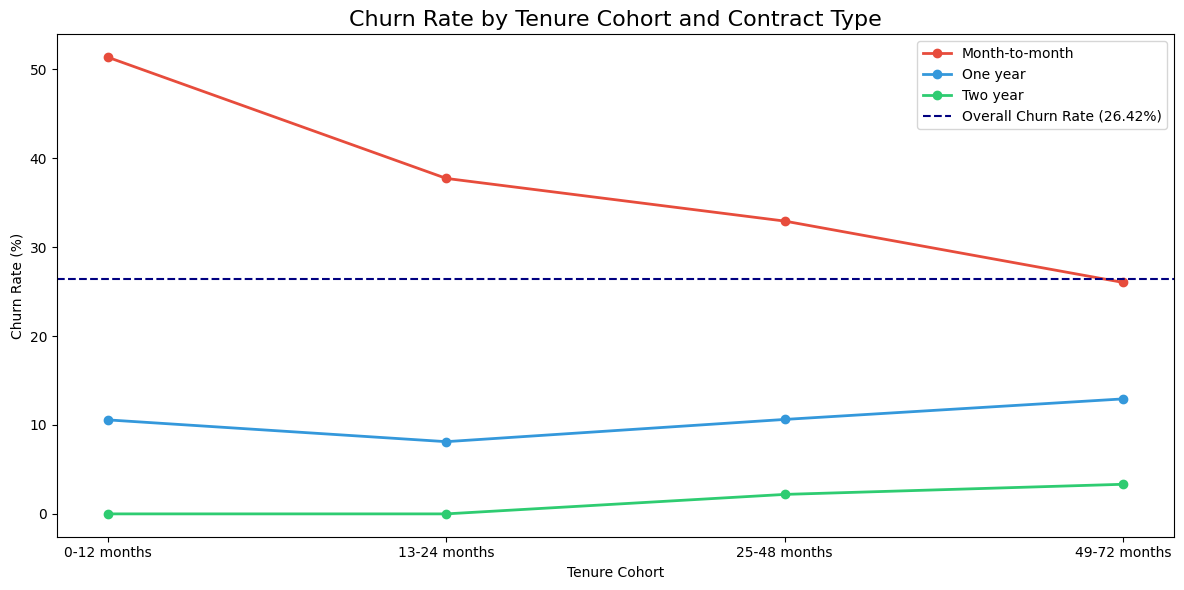

In [0]:
# Cohort analysis by contract type and tenure
cohort_contract = df_pandas.groupby(['tenure_cohort', 'Contract']).agg(
    total_customers=('Churn', 'count'),
    churned=('Churn', lambda x: (x == 'Yes').sum())
).reset_index()

cohort_contract['churn_rate_pct'] = (
    cohort_contract['churned'] / cohort_contract['total_customers'] * 100
).round(2)

# Plot
fig, ax = plt.subplots(figsize=(12, 6))

contracts = cohort_contract['Contract'].unique()
colors = ['#e74c3c', '#3498db', '#2ecc71']
x = range(len(cohort_contract['tenure_cohort'].unique()))

for i, contract in enumerate(contracts):
    data = cohort_contract[cohort_contract['Contract'] == contract]
    ax.plot(data['tenure_cohort'], data['churn_rate_pct'], 
            marker='o', label=contract, color=colors[i], linewidth=2)

ax.axhline(y=26.42, color='navy', linestyle='--', label='Overall Churn Rate (26.42%)')
ax.set_title('Churn Rate by Tenure Cohort and Contract Type', fontsize=16)
ax.set_xlabel('Tenure Cohort')
ax.set_ylabel('Churn Rate (%)')
ax.legend()
plt.tight_layout()
plt.show()